<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
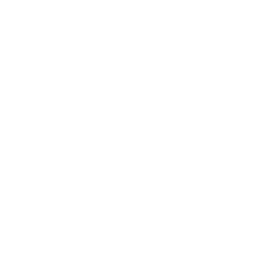
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Macro Dynamic Factor Model</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Macroeconomics / Time Series &nbsp;|&nbsp; July 2026</p>
</div>
</div>
</div>

## Executive Summary

Eight monthly US macroeconomic series — four real-activity gauges and four inflation gauges — carry far fewer than eight independent dimensions of information. Within each group the series move together; across the two groups they barely relate. This notebook fits a two-factor **maximum-likelihood factor model** with `PROC FACTOR` (`METHOD=ML NFACTORS=2 ROTATE=VARIMAX`) and recovers exactly the two forces you would expect: a **real-activity factor** and an **inflation factor**, together explaining roughly 72% of the panel's variation.

Just as important, the maximum-likelihood fit reports each series' **uniqueness** — the share of its movement that no common factor explains. That signal-versus-noise split is the reason to fit a factor model rather than take principal components, and it is what this notebook makes concrete.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| `macro_m.csv` | Eight monthly FRED series, stationarity-transformed | 540 |

The eight series are pulled from the Federal Reserve Economic Data (FRED) service, January 1980 through December 2024:

- **Real activity** — industrial production (`INDPRO`), nonfarm payrolls (`PAYEMS`), the unemployment rate (`UNRATE`), and capacity utilization (`TCU`).
- **Inflation** — headline CPI (`CPIAUCSL`), core CPI (`CPILFESL`), producer prices (`PPIACO`), and the PCE price index (`PCEPI`).

Levels of these series trend and drift, so each is transformed to a stationary rate before analysis: industrial production, payrolls, and the four price indexes become month-over-month growth rates (100 × log-difference), while the unemployment and capacity-utilization rates — already in percent — become simple month-over-month changes. The transformed panel is committed as `macro_m.csv` so the notebook runs the same data every time; it is the same snapshot locked by Jenner regression test `71040`, which checks the factor solution against an independent R `factanal` reference.

## Step 1 — Load the macro panel

Read the committed snapshot into a work dataset and summarize the eight transformed series. Each is a monthly rate, so the means sit near zero and the units are percentage points per month.

In [1]:
data macro;
    set "macro_m.csv";
run;

proc means data=macro n mean std min max maxdec=2;
    var indpro payems unrate tcu
        cpiaucsl cpilfesl ppiaco pcepi;
run;

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 indpro         540        0.12        0.99      -14.14        6.35
 payems         540        0.10        0.68      -14.58        3.42
 unrate         540       -0.00        0.50       -2.20       10.40
 tcu            540       -0.02        0.73       -9.70        4.33
 cpiaucsl       540        0.26        0.30       -1.79        1.42
 cpilfesl       540        0.27        0.21       -0.49        1.41
 ppiaco         540        0.21        0.98       -5.48        3.16
 pcepi          540        0.23        0.23       -1.19        1.22
 ------------------------------------------------------------------




NOTE: DATA macro


NOTE: Read 540 rows from macro_m.csv.
NOTE: Wrote macro (540 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.39 seconds
  cpu   0.39 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


All eight series span the full 540 months with no missing values, and each is centered near zero — the signature of a stationary rate. The activity gauges (industrial production, payrolls, capacity use) swing more widely than the inflation gauges, which is exactly why the factor model works on the **standardized** series: it puts every gauge on equal footing before separating common from specific variation.

## Step 2 — Two blocks in the correlation matrix

Before fitting any factors, look at the raw correlations. A factor model can only recover structure the data actually contain, so the correlation matrix previews what the factors will find.

   Pearson Correlation Coefficients, N = 540
          Prob > |r| under H0: Rho=0
              indpro    payems    unrate       tcu  cpiaucsl  cpilfesl    ppiaco     pcepi
--------  --------  --------  --------  --------  --------  --------  --------  --------
indpro     1.00000   0.75208  -0.72819   0.98327   0.16346   0.12112   0.22759   0.13461
              .       <.0001    <.0001    <.0001    0.0001    0.0048    <.0001    0.0017
payems     0.75208   1.00000  -0.94820   0.70675   0.18968   0.16681   0.23933   0.15527
            <.0001      .       <.0001    <.0001    <.0001    <.0001    <.0001    0.0003
unrate    -0.72819  -0.94820   1.00000  -0.69503  -0.15787  -0.12602  -0.23084  -0.12416
            <.0001    <.0001      .       <.0001    0.0002    0.0034    <.0001    0.0039
tcu        0.98327   0.70675  -0.69503   1.00000   0.15547   0.09906   0.24713   0.13697
            <.0001    <.0001    <.0001      .       0.0003    0.0213    <.0001    0.0014
cpiaucsl   0.16346   0.189


NOTE: PROC CORR data=macro

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


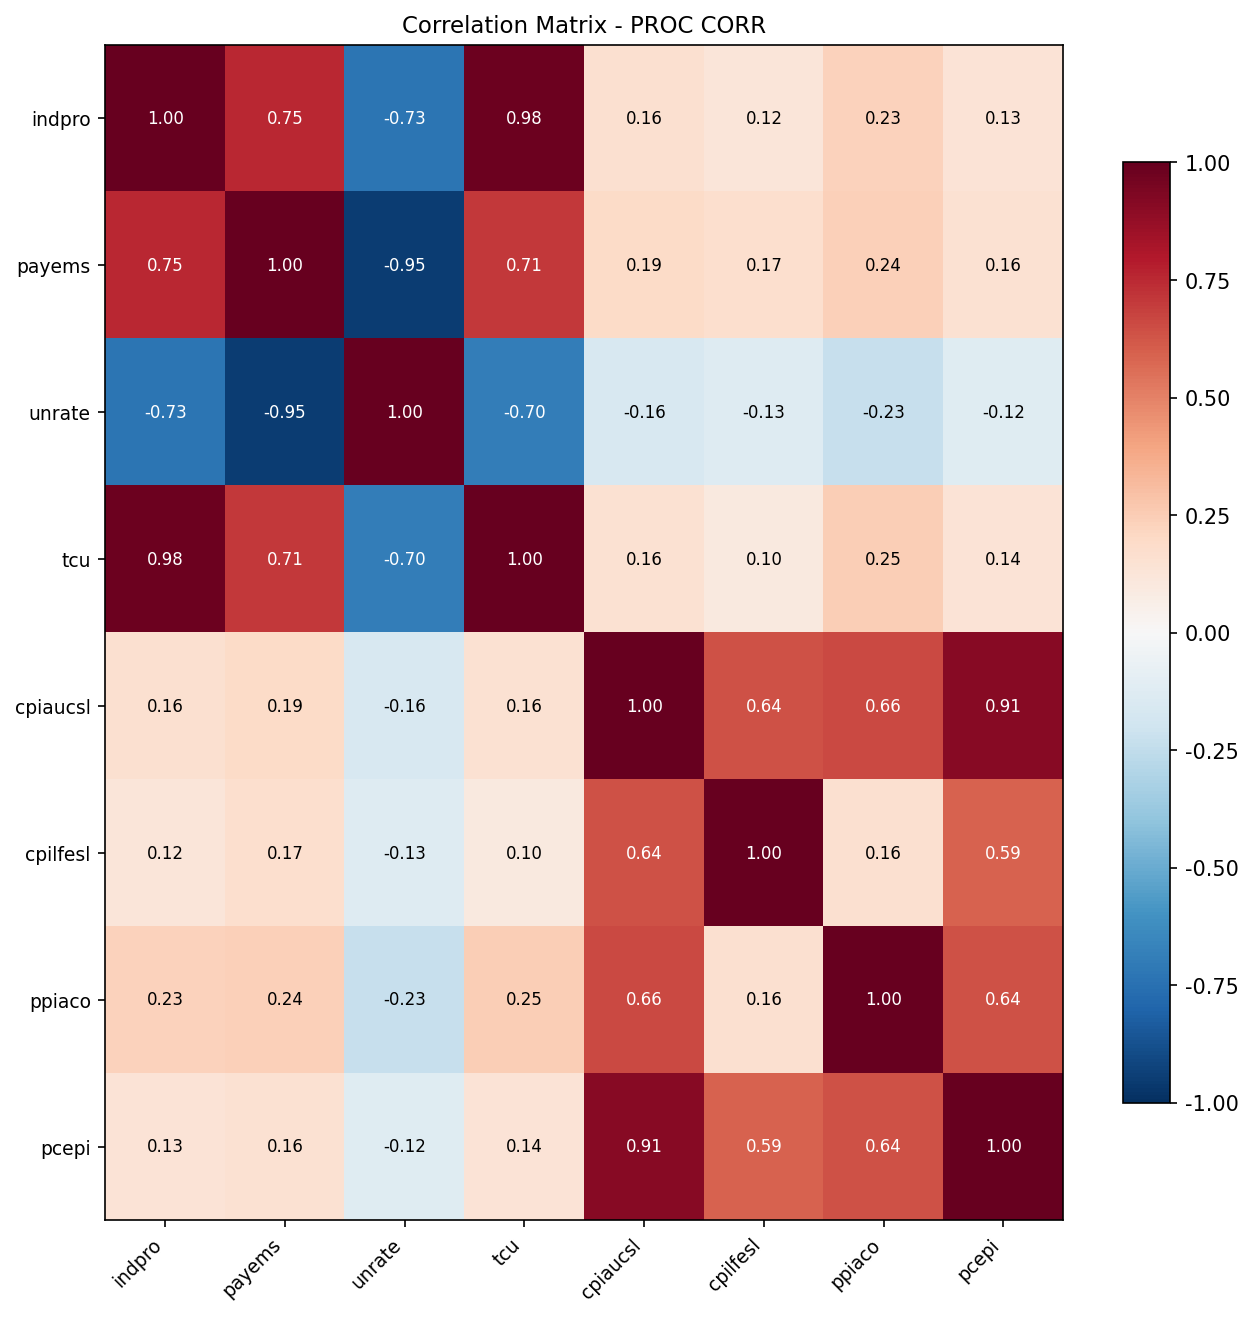

In [2]:
proc corr data=macro nosimple;
    var indpro payems unrate tcu
        cpiaucsl cpilfesl ppiaco pcepi;
run;

The matrix falls into two clear blocks. The four activity series correlate strongly among themselves — industrial production and capacity utilization move almost in lockstep (about 0.98), and payrolls and unemployment mirror each other (about −0.95). The four inflation series form their own block, with headline CPI and the PCE index near 0.91. Across the two blocks the correlations are small — mostly between 0.10 and 0.25.

That pattern — tight within each group, loose between them — is the fingerprint of a two-factor structure. The factor model formalizes it: one factor for whatever the activity series share, another for whatever the inflation series share.

## Step 3 — Two-factor maximum-likelihood model

Fit the factor model with `METHOD=ML`, which estimates the loadings and the specific variances together by maximum likelihood — the same estimator behind R's `factanal`. `NFACTORS=2` asks for the two common factors the correlation matrix implied, and `ROTATE=VARIMAX` spins them to simple structure so each factor is defined by a readable set of series.


Eigenvalues of the Correlation Matrix
             Eigenvalue   Difference   Proportion   Cumulative
  Factor 1       3.8506       1.4271       0.4813       0.4813
  Factor 2       2.4235       1.5838       0.3029       0.7843
  Factor 3       0.8397       0.3155       0.1050       0.8892
  Factor 4       0.5242       0.3143       0.0655       0.9547
  Factor 5       0.2099       0.1225       0.0262       0.9810
  Factor 6       0.0874       0.0359       0.0109       0.9919
  Factor 7       0.0515       0.0385       0.0064       0.9984
  Factor 8       0.0131       0.0000       0.0016       1.0000

Factor Pattern
                Factor1    Factor2
indpro           0.9938     0.0867
payems           0.7427     0.1330
unrate          -0.7233    -0.1026
tcu              0.9820     0.0799
cpiaucsl         0.0777     0.9945
cpilfesl         0.0643     0.6329
ppiaco           0.1763     0.6512
pcepi            0.0575     0.9073

Final Communality Estimates
indpro           0.9950
payems    


NOTE: PROC FACTOR data=macro

NOTE: Using Python numpy version 2.4.4
NOTE: ODS plot written: factor_scree.spec.json
NOTE: PROC FACTOR completed.


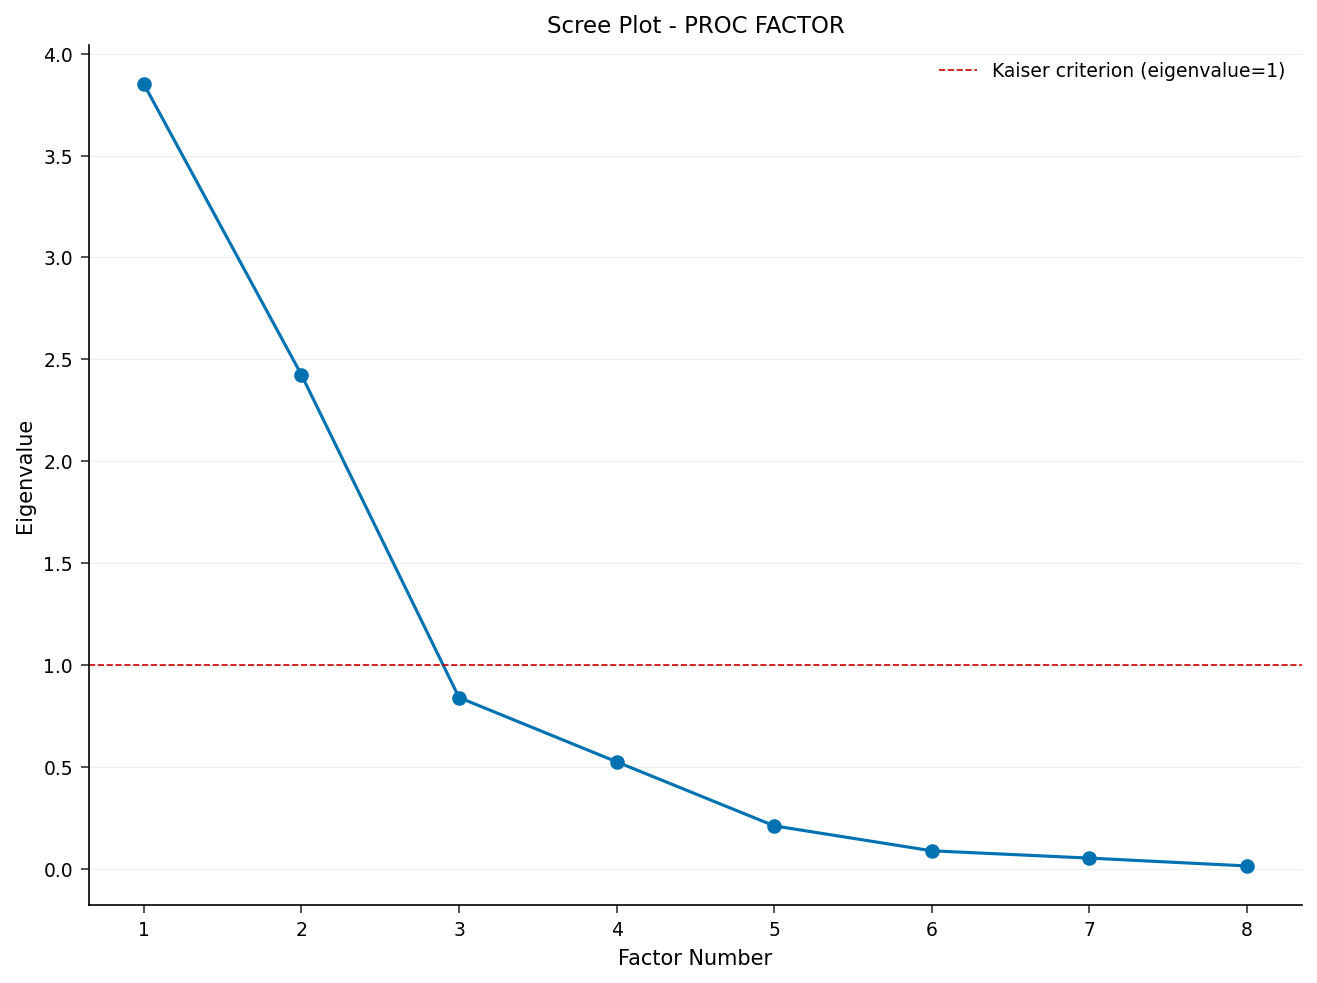

In [3]:
proc factor data=macro method=ml nfactors=2
            rotate=varimax;
    var indpro payems unrate tcu
        cpiaucsl cpilfesl ppiaco pcepi;
run;

The eigenvalue table and scree plot confirm the choice of two factors: only the first two eigenvalues (about 3.85 and 2.42) clear the Kaiser threshold of 1, and the curve elbows sharply after the second. The rotated pattern splits exactly along the two blocks. **Factor 1 is real activity**: it loads positively on industrial production (about 0.99), capacity use (0.98), and payrolls (0.74), and negatively on unemployment (−0.72) — the business cycle in one series. **Factor 2 is inflation**: it loads on all four price gauges at once, led by headline CPI (0.99) and the PCE index (0.91). Cross-loadings sit near zero, the mark of a clean rotation. Together the two factors carry about 72% of the panel's standardized variance (sums of squared loadings near 3.07 and 2.68).

The **final communality estimates** tell the second half of the story. Industrial production, capacity use, and headline CPI have communalities near 0.99 — almost pure readings of their factor. Core CPI and producer prices sit near 0.4, so more than half of their month-to-month movement is *specific*: supply shocks and category quirks the common inflation factor never touches. Payrolls and unemployment land in between, near 0.55, sharing the activity factor while keeping sizable labor-market dynamics of their own.

## Interpreting the Results

Eight macro series collapse to two interpretable forces — real activity and inflation — that together account for roughly 72% of their common movement. That is the dimension-reduction payoff: a nowcasting or forecasting model can track two factor scores instead of eight noisy series, and the two factors are the ones a macroeconomist would name on sight.

The maximum-likelihood fit adds what a principal-component summary cannot: an honest accounting of what each series does **not** share. Core CPI and producer prices are revealed as largely idiosyncratic at the monthly frequency, while industrial production and headline CPI are near-perfect proxies for their factors. Reading those uniquenesses — not just the loadings — is the reason to reach for `METHOD=ML` when you want to separate the common signal in a macro panel from the series-specific noise around it.